In [1]:
import sys
sys.path.insert(0, '../')
import pandas as pd
import numpy as np
import yaml
import unicodedata
from helpers_finalizacion_carrera import get_egresados_biologia, plot_todos_anios_egreso, plot_tiempo_cursando, plot_todos_anios_egreso_solo_cantidad_y_k

In [2]:
personas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv')
personas['dni'] = personas['dni'].astype(str)
actas = pd.read_csv('../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv', encoding='latin-1', dtype={'dni': str})

In [3]:
#cambio los registros de la columna 'materia' para que esten en mayuscula, sin espacios al principio ni al final, y sin tildes.
actas['materia'] = actas['materia'].str.upper().str.strip()
actas['materia'] = actas['materia'].apply(lambda x: unicodedata.normalize('NFKD', x).encode('ASCII', 'ignore').decode('ASCII'))

## Biología

In [4]:
materias_biologia = (
    actas[actas['carrera'] == 'Licenciatura en Ciencias Biológicas']['materia']
    .value_counts()
    .rename_axis('materia')
    .reset_index(name='cantidad')
)

materias_biologia

,materia,cantidad
0,INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR,8643
1,INTRODUCCION A LA BOTANICA,7801
2,ANALISIS MATEMATICO I,7505
3,QUIMICA GENERAL E INORGANICA I,7181
4,ELEMENTOS DE CALCULO NUMERICO,6460
...,...,...
159,ELEMENTOS DE TEORIA DE NUMEROS,1
160,BIOESTRATIGRAFIA,1
161,PALEONTOLOGIA DE INVERTEBRADOS,1
162,FOTOQUIMICA Y ESPECTROSCOPIA,1


Notamos que los distintos planes ofrecen materias distintas, incluso el plan de 1984 cuenta con un listado más extenso de materias.

In [5]:
with open('../../constants/materias_biologia.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias_plan1984 = [m for m in config['planes'][0]['materias']]

In [6]:
len(materias_plan1984)

141

In [7]:
with open('../../constants/materias_biologia.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias_plan2019 = [m for m in config['planes'][1]['materias']]

In [8]:
len(materias_plan2019)

105

Juntamos las listas

In [9]:
with open('../../constants/materias_biologia.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
    materias = [m for plan in config['planes'] for m in plan['materias']]

In [10]:
materias = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias]
materias = list(set(materias))
materias

['AGROBIOTECNOLOGIA',
 'ANATOMIA ANIMAL COMPARADA (UNLP)',
 'CLIMATOLOGIA',
 'MICOLOGIA EXPERIMENTAL',
 'QUIMICA BIOLOGICA II B (ESTRUCTURA Y FUNCION DE BIOMOLECULAS)',
 'INVERTEBRADOS II',
 'GEOBOTANICA',
 'TRANSDUCCION DE SENALES Y CANCER',
 'BIOTECNOLOGIA VEGETAL',
 'INTRODUCCION A LA BIOINFORMATICA MOLECULAR',
 'FISIOLOGIA VEGETAL',
 'HELMINTOLOGIA',
 'MICROPALEONTOLOGIA',
 'BOTANICA ECONOMICA',
 'SISTEMATICA TEORICA',
 'ANALISIS I',
 'GEOLOGIA MARINA',
 'CONCEPTOS Y PROBLEMAS DE LA FILOSOFIA DE LA CIENCIA',
 'ANALISIS DE AMBIENTES CONTINENTALES',
 'BIOTECNOLOGIA INDUSTRIAL Y MICROBIOLOGIA APLICADA',
 'BIOLOGIA DEL DESARROLLO REPRODUCTIVO DE PLANTAS',
 'VERTEBRADOS',
 'EMBRIOLOGIA VEGETAL',
 'OCEANOGRAFIA FISICA',
 'INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR',
 'FISICA II',
 'ANALISIS BIOLOGICOS I',
 'FISIOLOGIA DE INSECTOS',
 'BIOLOGIA DE LA CONSERVACION',
 'BIOLOGIA SENSORIAL ANIMAL',
 'FITOPATOLOGIA',
 'GENETICA BACTERIANA',
 'INGENIERIA GENETICA',
 'QUIMICA FARMACOLOGICA',


In [11]:
len(materias)

167

Sin embargo, al invetigar los planes de ambas carreras, nos interamos de que lo que debería cambiar entre ambos planes es que en 2019 se agregó una materia obligatoria, "Evolución" y cambio lo necesario para aprobar el ciclo superior. 

Intentemos verificar, por lo menos con unos ejemplos, que esto se ve reflejado en los datos

In [12]:
materias_biologia[materias_biologia['materia'].isin(materias)].shape

(130, 2)

In [13]:
materias_en_actas = materias_biologia['materia'].tolist()

In [14]:
[m for m in materias if m not in materias_en_actas]

['ANATOMIA ANIMAL COMPARADA (UNLP)',
 'CLIMATOLOGIA',
 'GEOBOTANICA',
 'HELMINTOLOGIA',
 'MICROPALEONTOLOGIA',
 'CONCEPTOS Y PROBLEMAS DE LA FILOSOFIA DE LA CIENCIA',
 'ANALISIS DE AMBIENTES CONTINENTALES',
 'BIOLOGIA DEL DESARROLLO REPRODUCTIVO DE PLANTAS',
 'GENETICA',
 'ECOFISIOLOGIA VEGETAL',
 'INVERTEBRADOS II: CRUSTACEA Y CHELICERATA',
 'MICOLOGIA',
 'GENETICA MOLECULAR BACTERIANA I Y GENETICA MOLECULAR BACTERIANA II',
 'DASONOMIA (FAUBA)',
 'FARMACOLOGIA (FFYB UBA)',
 'ECOLOGIA E EPIDEMIOLOGIA DE INFECCIONES PARASITARIAS',
 'BIOINFORMATICA Y BIOLOGIA COMPUTACIONAL',
 'PALINOESTRATIGRAFIA',
 'SEDIMENTOLOGIA',
 'PALINOLOGIA',
 'HERPETOLOGIA (UNLP)',
 'FOTOINTERPRETACION',
 'PLANIFICACION Y CONSERVACION DEL USO DE LA TIERRA (FAUBA)',
 'BIOLOGIA ANIMAL SENSORIAL',
 'OCEANOGRAFIA GENERAL',
 'PLANCTOLOGIA',
 'PROTECCION Y CONSERVACION DE LA NATURALEZA (UNLP)',
 'PROTOZOOLOGIA',
 'ANTROPOLOGIA BIOLOGICA Y PALEO ANTROPOLOGIA (FYL UBA)',
 'TECNICAS EN BIOQUIMICA Y BIOLOGIA MOLECULAR',
 '

Cuando revisamos que esten las materias obligatorias, encuentro que solo falta GENETICA del plan de 2019, sospecho que se sigue llamando GENETICA I o se le colocó un nombre similar, podemos revisar ejemplos.

In [15]:
materias_troncales_bio = [
    "Biometría",
    "Ecología General",
    "Fisica II",
    "Genética I",
    "Introducción a la Biología Molecular y Celular",
    "Introducción a la Botánica",
    "Introducción a la Zoología",
    "Análisis Matemático I",
    "Elementos de Cálculo Numérico",
    "Física I",
    "Química Biológica",
    "Química General e Inorgánica I",
    "Química Orgánica",
]
materias_troncales_bio = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias_troncales_bio]

In [16]:
[m for m in materias_troncales_bio if m not in materias_en_actas]

[]

In [17]:
materias_troncales_plan2019 = [
    "Biometria",
    "Ecología General",
    "Electromagnetismo y Óptica",
    "Evolución",
    "Genética",
    "Introducción a la Biología Molecular y Celular",
    "Introducción a la Botánica",
    "Introducción a la Zoología",
    "Matemática I",
    "Matemática II",
    "Mecánica y Termodinámica",
    "Química Biológica",
    "Química General e Inorgánica I",
    "Química Orgánica",
]
materias_troncales_plan2019 = [unicodedata.normalize('NFKD', m).encode('ASCII', 'ignore').decode('ASCII').upper() for m in materias_troncales_plan2019]

In [18]:
[m for m in materias_troncales_plan2019 if m not in materias_en_actas]

['GENETICA']

Algunas de las que no se encuentran son del plan nuevo:

* OCEANOGRAFIA GENERAL
* GENETICA <-- hay que revisar porque es del ciclo troncal, no debería faltar

In [19]:
materias_biologia[materias_biologia['materia'].isin(materias_troncales_bio)].sort_values(by='cantidad', ascending=False)

,materia,cantidad
0,INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR,8643
1,INTRODUCCION A LA BOTANICA,7801
2,ANALISIS MATEMATICO I,7505
3,QUIMICA GENERAL E INORGANICA I,7181
4,ELEMENTOS DE CALCULO NUMERICO,6460
5,INTRODUCCION A LA ZOOLOGIA,6383
6,BIOMETRIA,6167
7,GENETICA I,5427
8,QUIMICA ORGANICA,5321
9,ECOLOGIA GENERAL,5308


In [20]:
materias_biologia[materias_biologia['materia'].isin(materias_troncales_plan2019)].sort_values(by='cantidad', ascending=False)

,materia,cantidad
0,INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR,8643
1,INTRODUCCION A LA BOTANICA,7801
3,QUIMICA GENERAL E INORGANICA I,7181
5,INTRODUCCION A LA ZOOLOGIA,6383
6,BIOMETRIA,6167
8,QUIMICA ORGANICA,5321
9,ECOLOGIA GENERAL,5308
10,QUIMICA BIOLOGICA,5263
11,EVOLUCION,4490
12,MATEMATICA I,4316


In [21]:
biologos = personas[personas['carrera_principal'] == 'Licenciatura en Ciencias Biológicas'][['dni', 'año_inscripcion_facultad']]

In [22]:
actas_biologos = actas[actas['dni'].isin(biologos['dni'])]

In [23]:
actas_biologos = actas_biologos.merge(biologos, on='dni', how='left').sort_values(by=['año_inscripcion_facultad'])

In [24]:
actas_biologos[(actas_biologos['año_inscripcion_facultad'] >= 2019) & (actas_biologos['materia'].isin(materias_troncales_plan2019))]['materia'].value_counts()

materia
MATEMATICA I                                      4341
INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR    3434
INTRODUCCION A LA BOTANICA                        3252
QUIMICA ORGANICA                                  2210
MATEMATICA II                                     2158
INTRODUCCION A LA ZOOLOGIA                        2143
BIOMETRIA                                         2013
QUIMICA GENERAL E INORGANICA I                    1546
QUIMICA BIOLOGICA                                 1463
ECOLOGIA GENERAL                                  1410
ELECTROMAGNETISMO Y OPTICA                        1259
MECANICA Y TERMODINAMICA                           822
EVOLUCION                                          597
Name: count, dtype: int64

In [25]:
actas_biologos[(actas_biologos['año_inscripcion_facultad'] >= 2019) & (actas_biologos['materia'].isin(materias_troncales_bio))]['materia'].value_counts()

materia
INTRODUCCION A LA BIOLOGIA MOLECULAR Y CELULAR    3434
INTRODUCCION A LA BOTANICA                        3252
QUIMICA ORGANICA                                  2210
INTRODUCCION A LA ZOOLOGIA                        2143
BIOMETRIA                                         2013
QUIMICA GENERAL E INORGANICA I                    1546
QUIMICA BIOLOGICA                                 1463
ECOLOGIA GENERAL                                  1410
GENETICA I                                        1217
ANALISIS MATEMATICO I                              128
ELEMENTOS DE CALCULO NUMERICO                       64
Name: count, dtype: int64

## Calculo de egresados

* Si tiene tesis, se recibió y lo hizo en el año de la tesis
* Si no tiene tesis, en el plan nuevo en realidad no se podría haber recibido, pues la tesis es obligatoria. Sin embargo, con el plan de 1984 podría haberlo hecho si tiene 9 materias (antes de 2012 no se registra la tesis), entonces:
    * Si cursó evolución en 2019 o años posteriores, asumimos que es del plan de 2019:
        * si tiene 14 materias obligatorias (consideramos el listado con los nombres de 1984 y 2019, pues a veces tardan en cambiar el nombre de las materias) y 6 del ciclo superior (pues 7 es el lo mínimos que pueden hacer para recibirse y consideramos el 90%) → se recibió y lo hizo en el año de la última materia que cursara entre esas 14+6 materias
        * caso contrario, no se recibió
    * Si no cursó Evolución o lo hizo antes de 2019, consideramos que es del plan de 1984 —> debe tener las 13 materias obligatorias + 8 materias del ciclo superior (pues podía hacer 9 materias + tesis o 10 materias)

In [26]:
egresados_bio = get_egresados_biologia(
    ['Licenciatura en Ciencias Biológicas'],
    '../../constants/materias_biologia.yaml',
    '../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_personas_desde_2005.csv',
    '../../../assets/bronze/FCEN/FCEN_oficial_2005_2025/reporte_actas_desde_2005.csv',
    min_obligatorias_1984 = 13,
    min_ciclo_superior_1984 = 8,
    min_obligatorias_2019 = 14,
    min_ciclo_superior_2019 = 6,
)

In [27]:
actas_biologos[actas_biologos['materia'] == 'TESIS DE LICENCIATURA'].assign(
    anio=lambda x: pd.to_datetime(x['fecha']).dt.year
).groupby('anio').size().reset_index(name='cantidad')

,anio,cantidad
0,2019,1
1,2020,2
2,2021,1
3,2022,16
4,2023,38
5,2024,93
6,2025,126


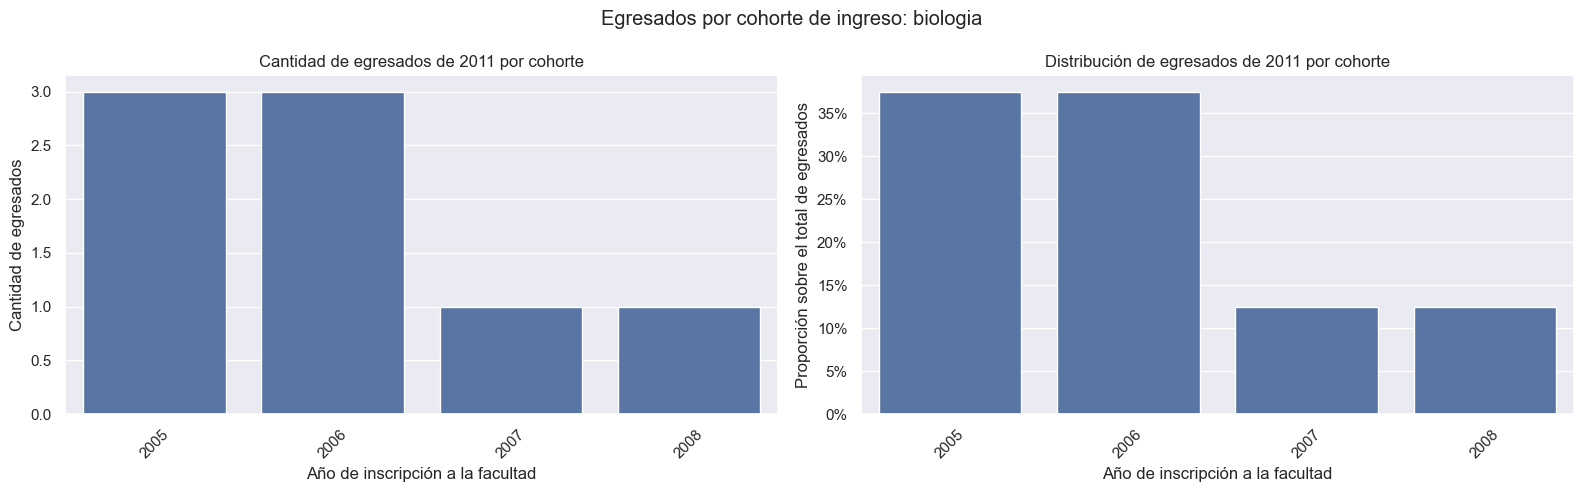

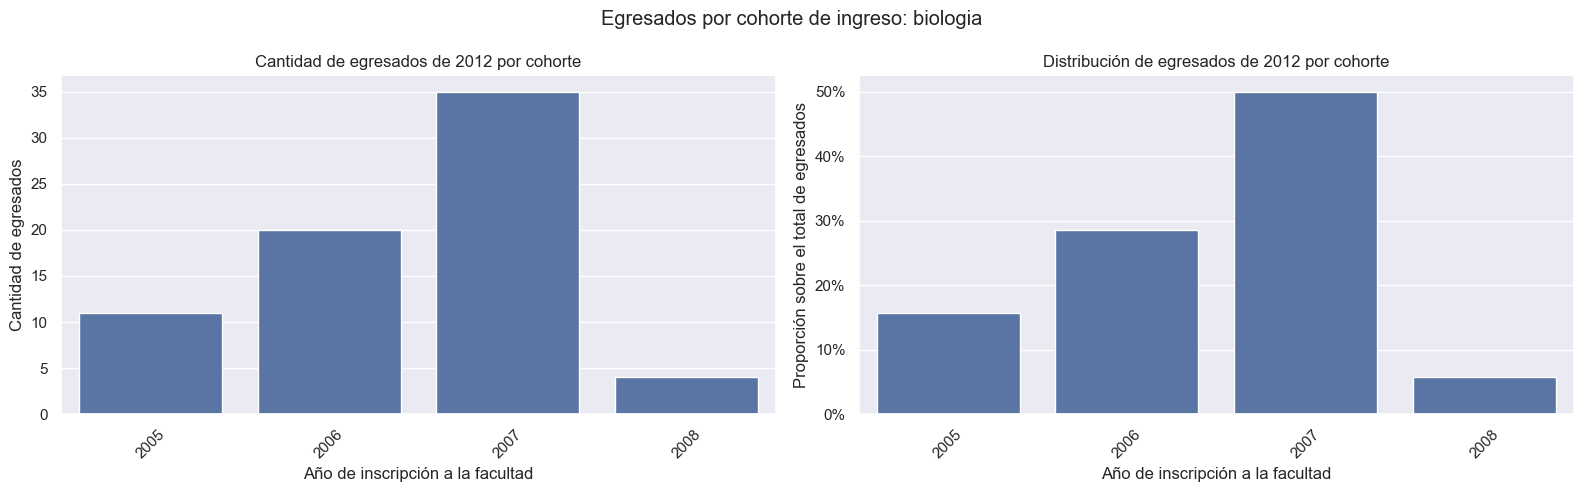

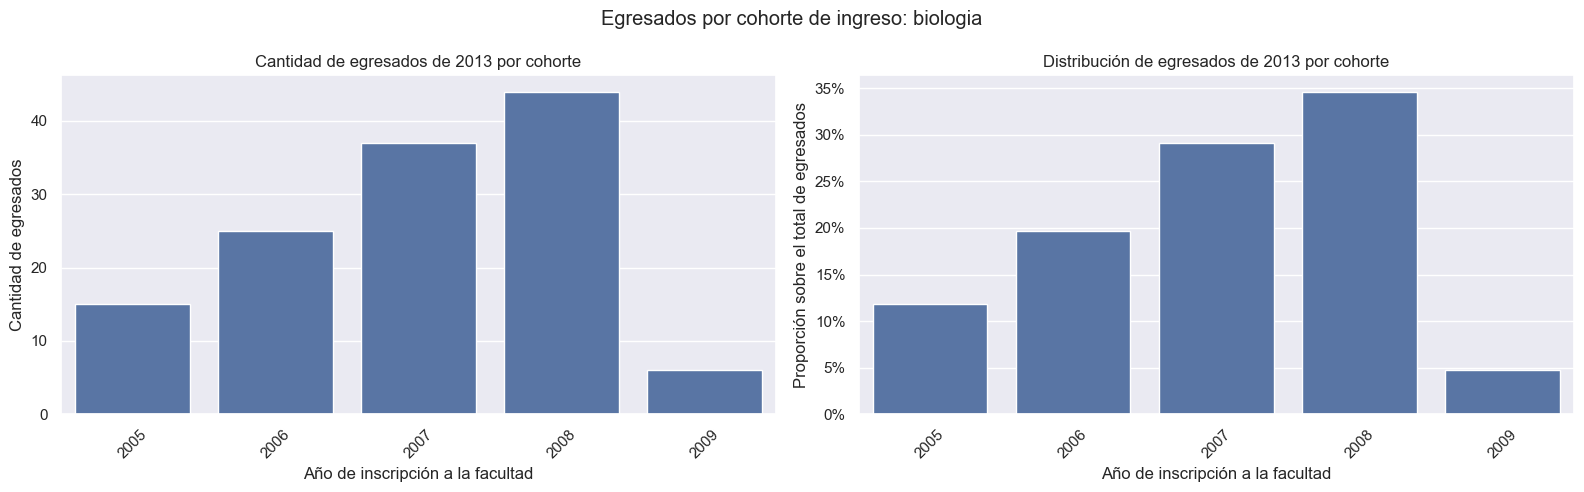

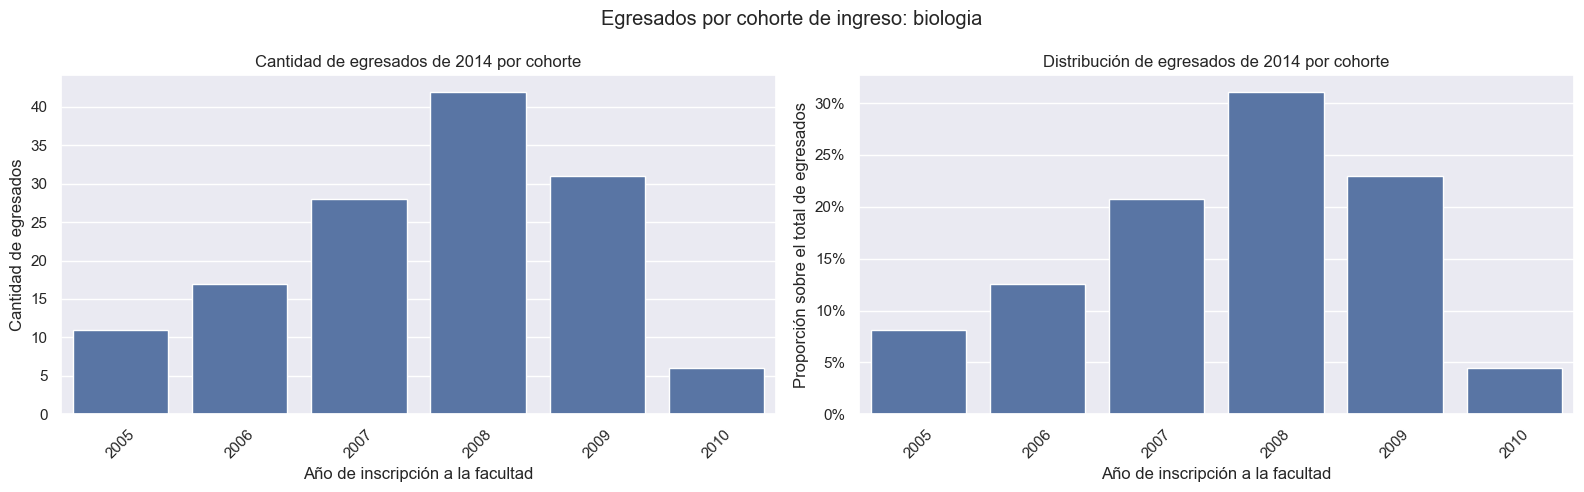

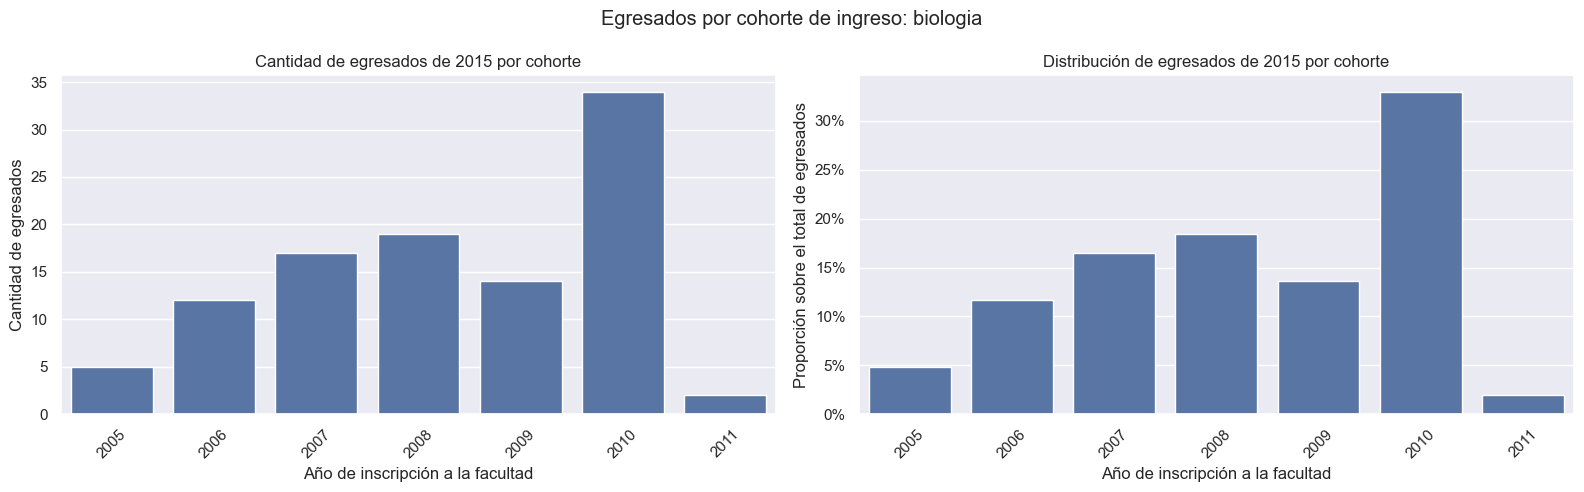

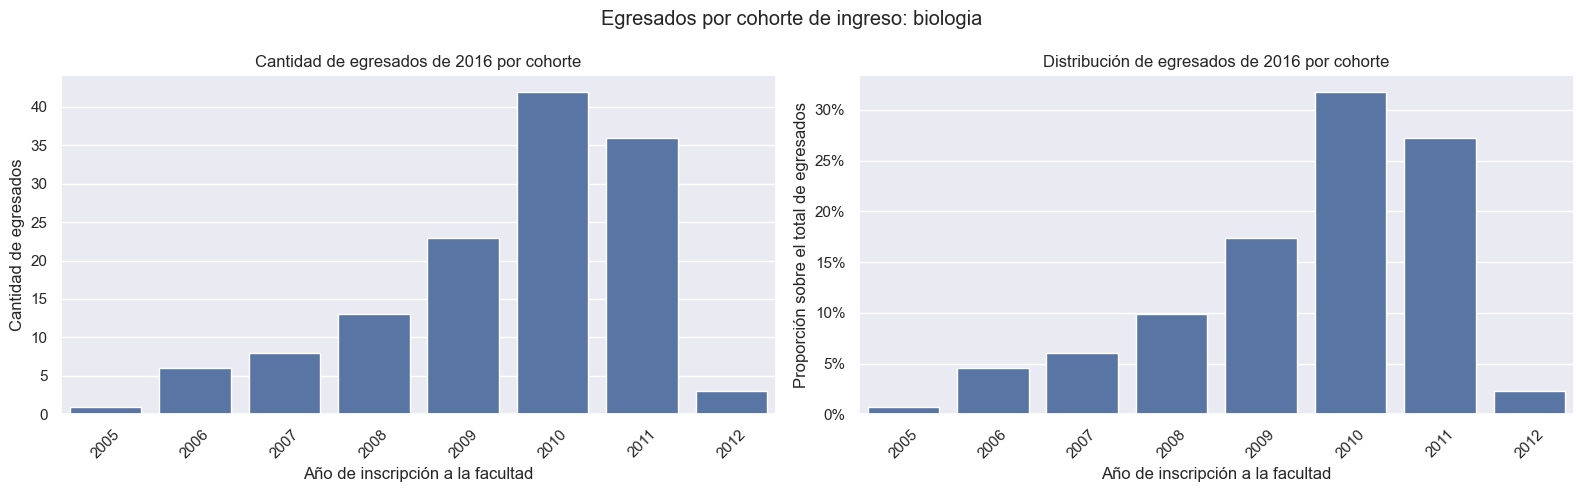

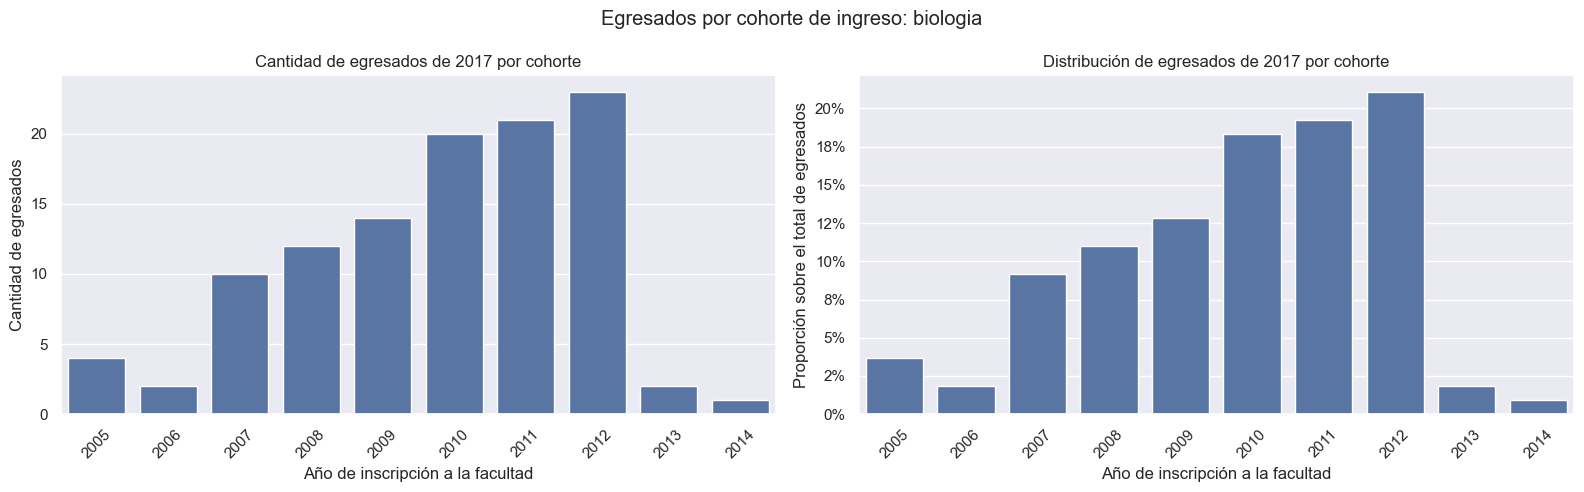

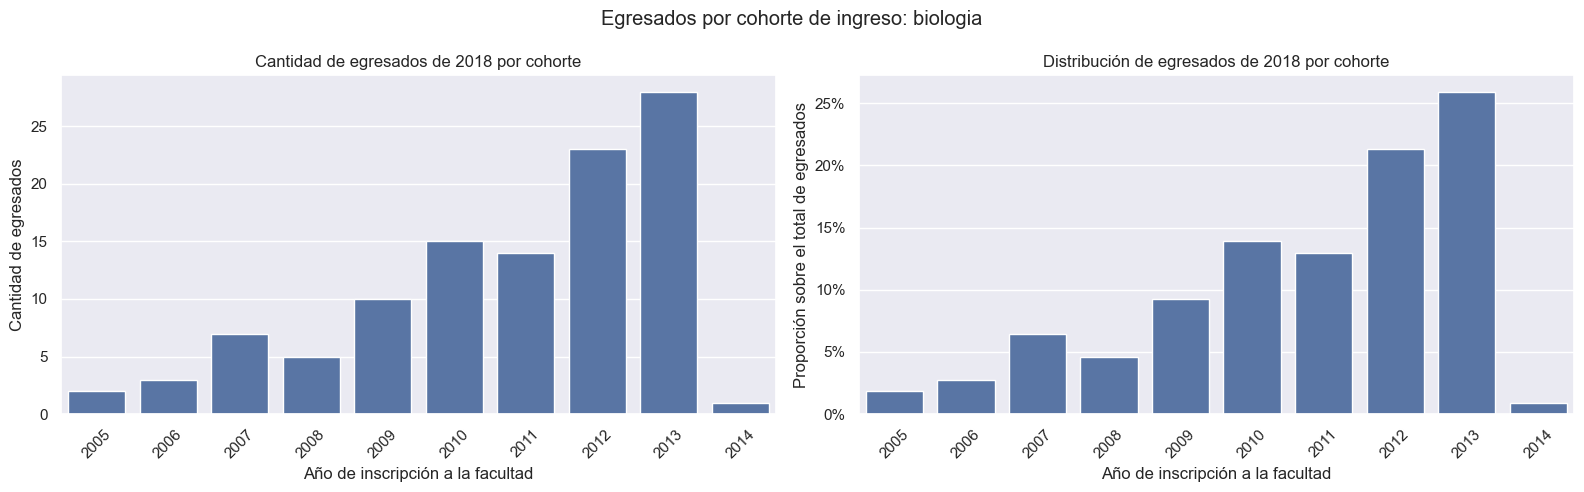

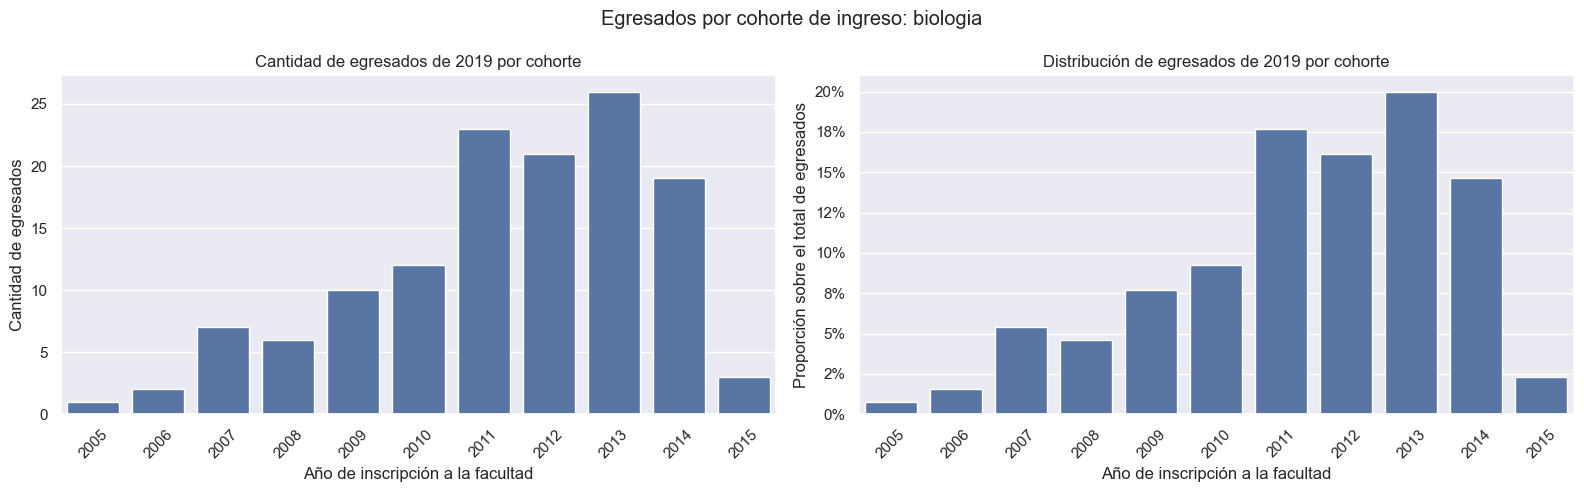

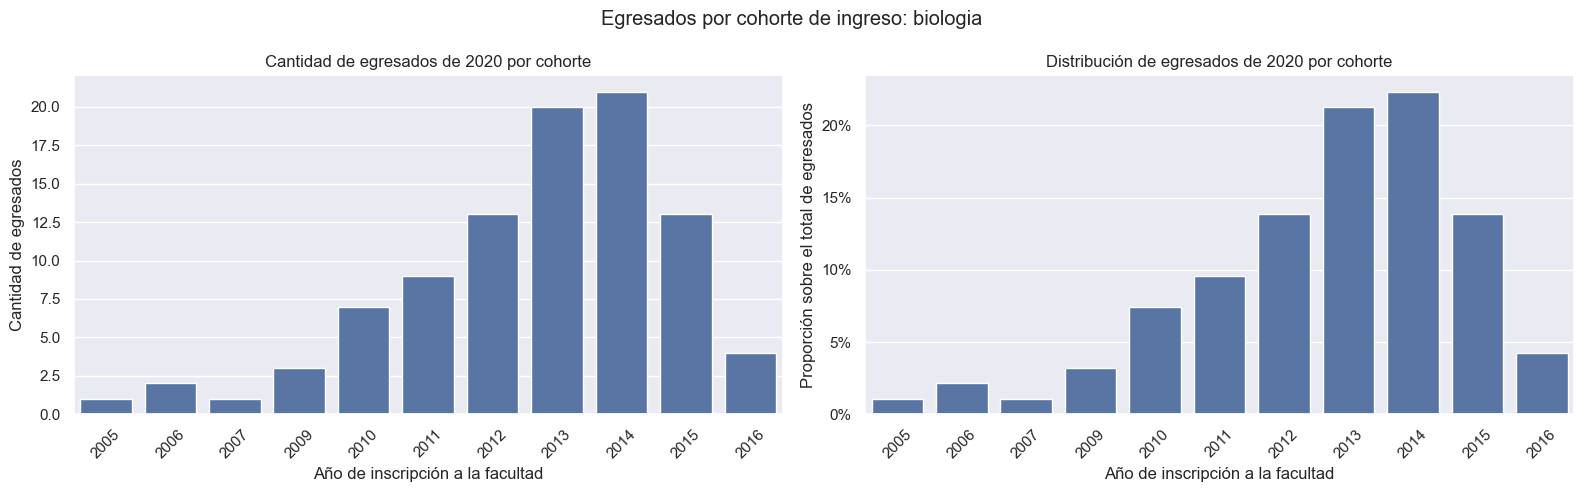

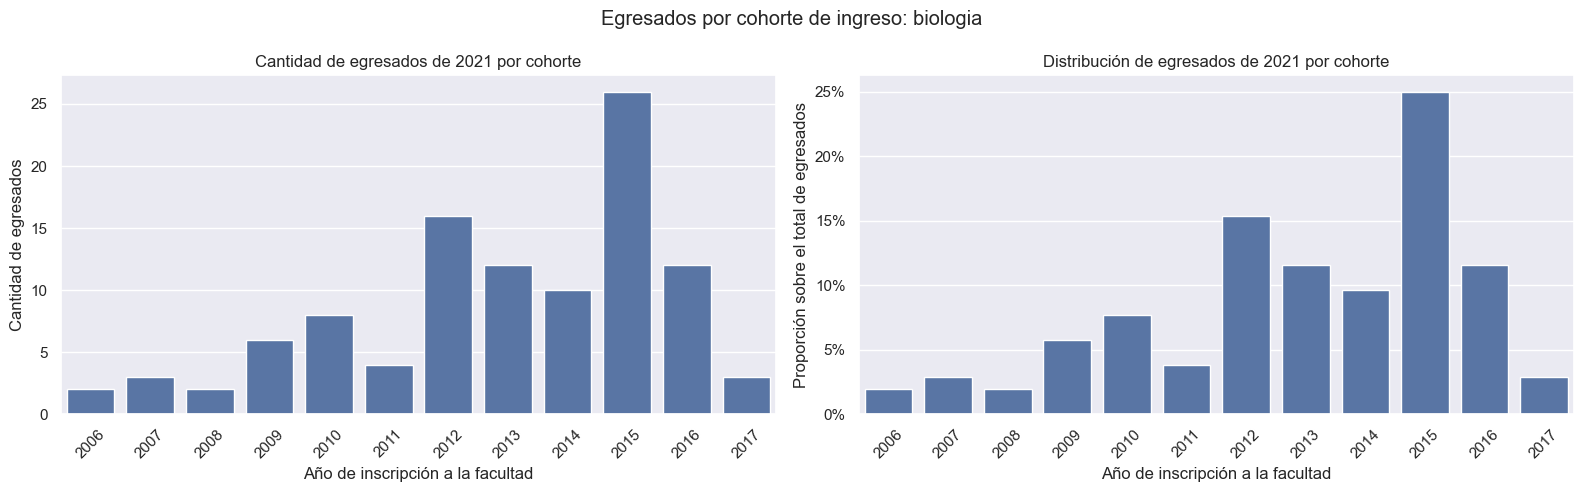

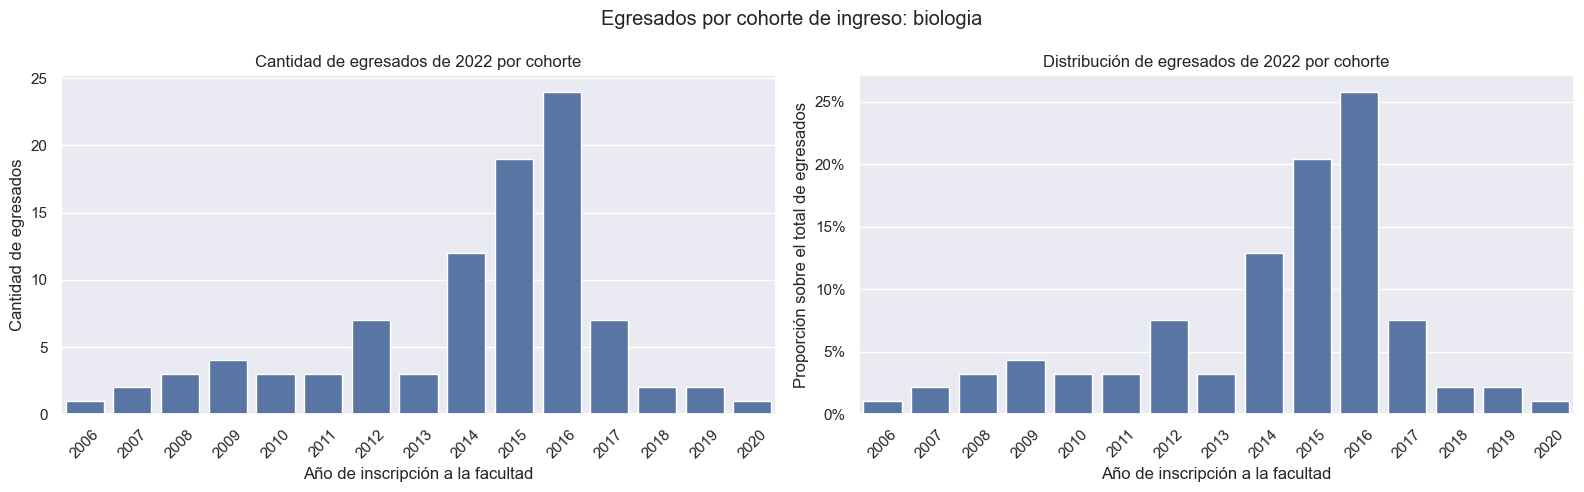

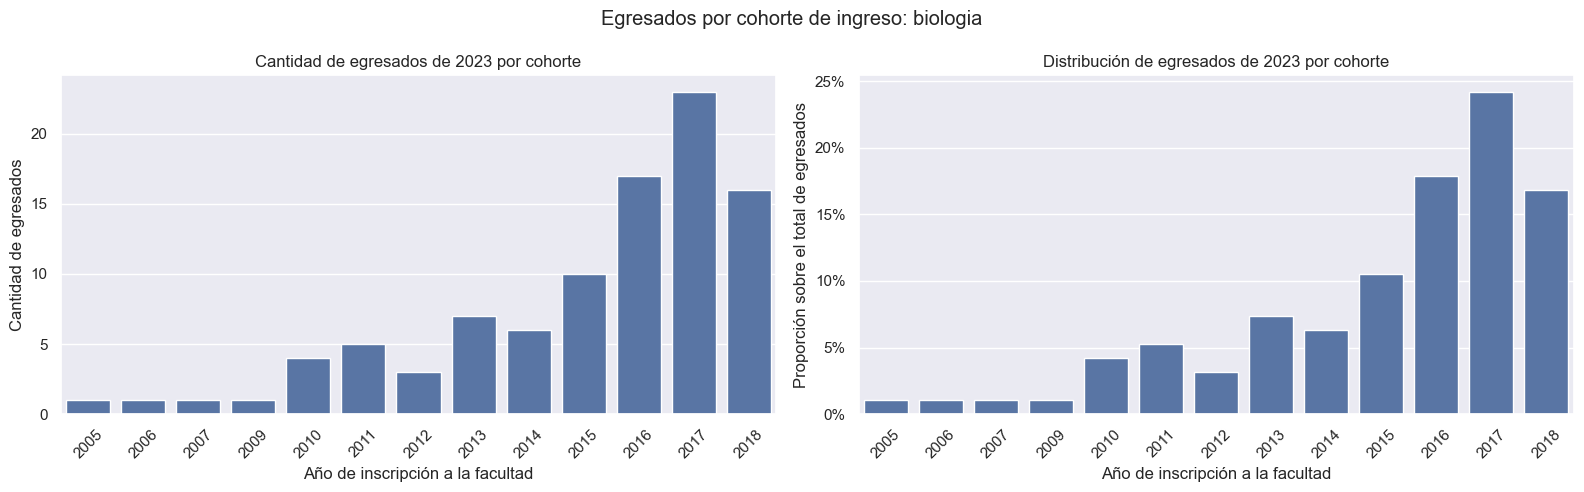

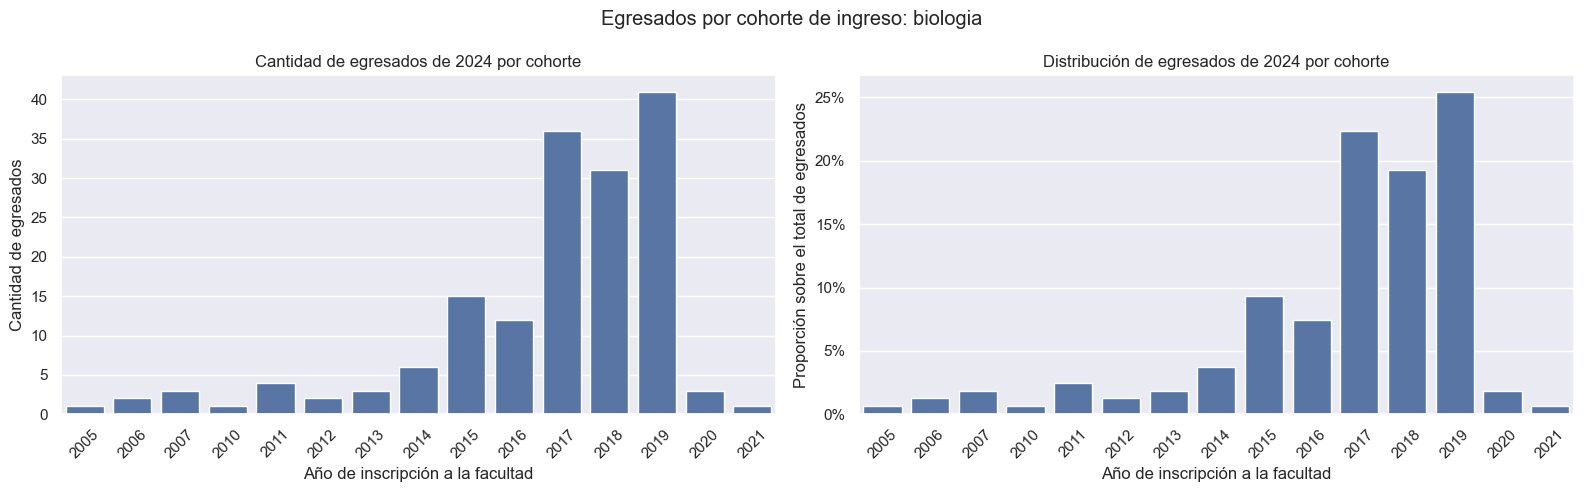

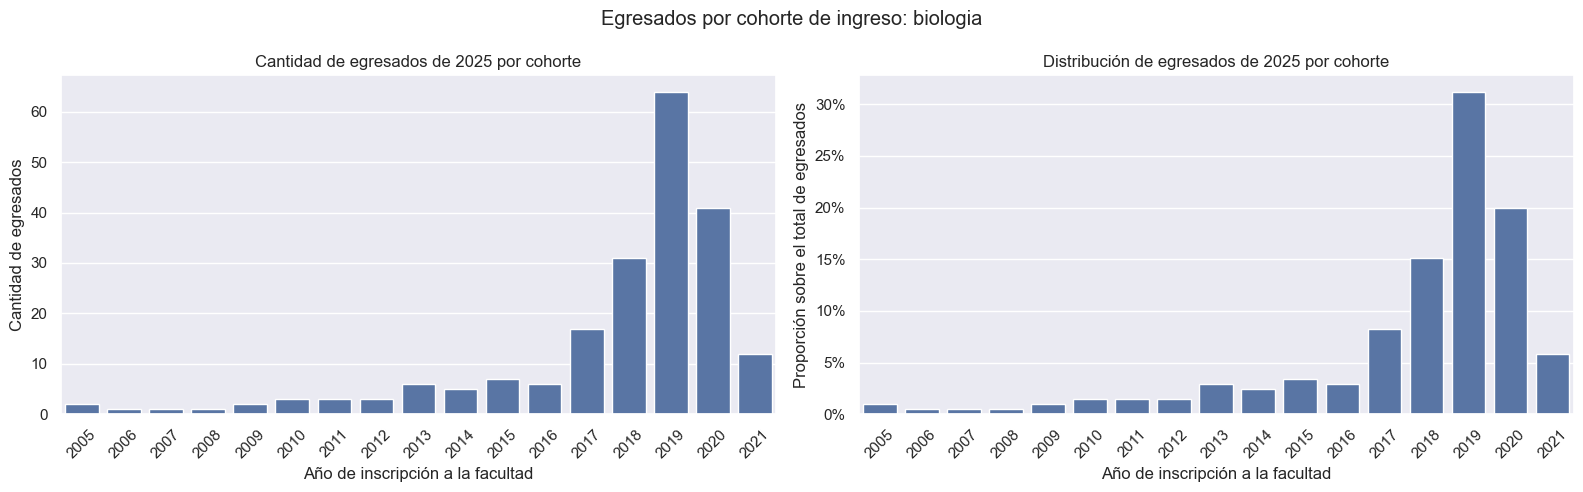

In [28]:
plot_todos_anios_egreso(egresados_bio, 'Biología')

In [29]:
egresados_biologia_2014_2019 = pd.DataFrame()
for anio in range(2014, 2020):
    egresados = pd.read_csv(f'../../../assets/datos_agrupados/biologia/resumen_egresados_biologia_{anio}.csv')
    egresados_biologia_2014_2019 = pd.concat([egresados_biologia_2014_2019, egresados])

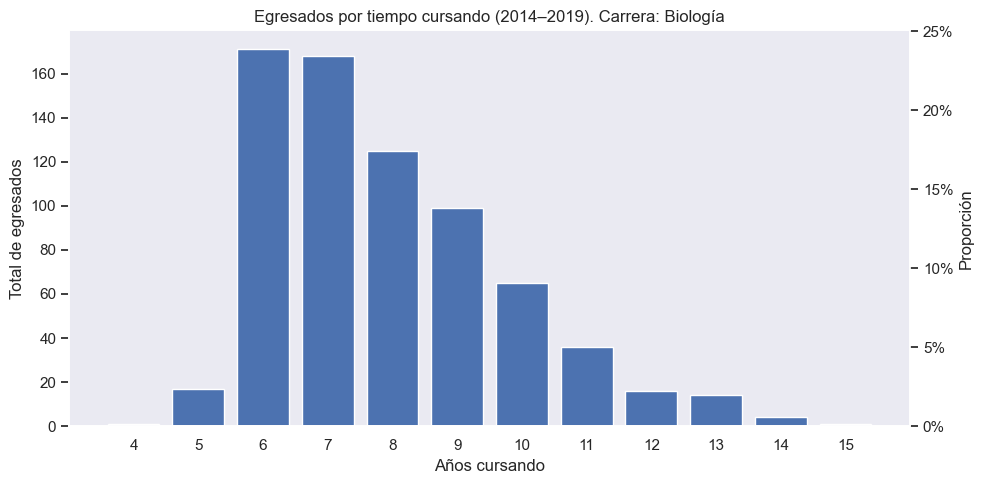

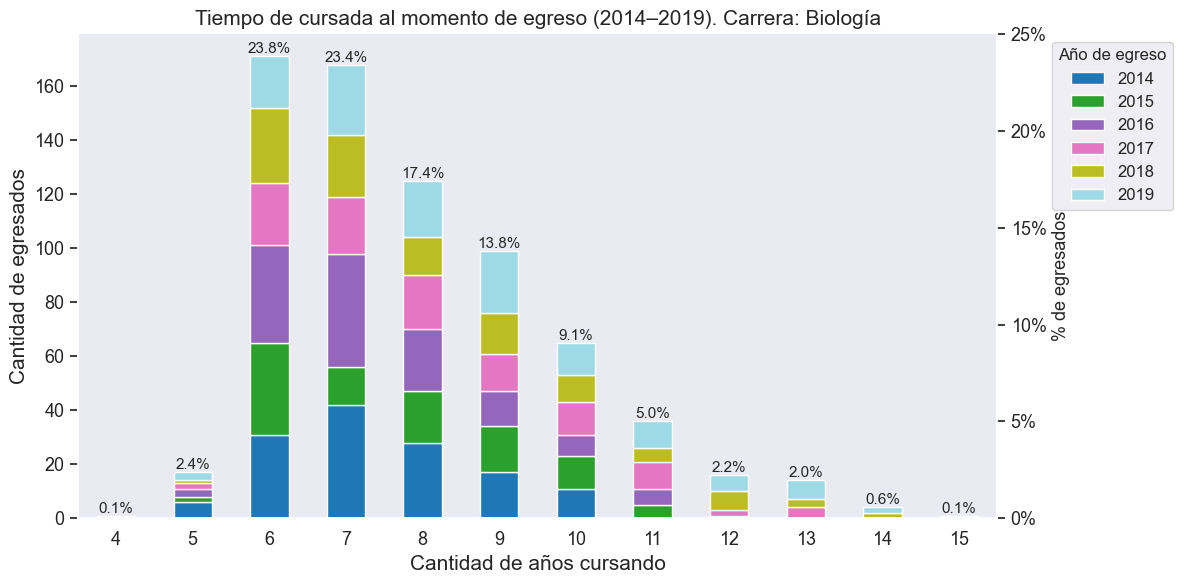

 tiempo_cursando  total_egreso
               4             1
               5            17
               6           171
               7           168
               8           125
               9            99
              10            65
              11            36
              12            16
              13            14
              14             4
              15             1
anio_egreso      2014  2015  2016  2017  2018  2019
tiempo_cursando                                    
4                   0     0     0     1     0     0
5                   6     2     3     2     1     3
6                  31    34    36    23    28    19
7                  42    14    42    21    23    26
8                  28    19    23    20    14    21
9                  17    17    13    14    15    23
10                 11    12     8    12    10    12
11                  0     5     6    10     5    10
12                  0     0     1     2     7     6
13                  0    

In [30]:
total_por_tiempo, resumen_por_cohorte, promedio_ponderado = plot_tiempo_cursando(egresados_biologia_2014_2019, 'Biología', anio_desde=2014, anio_hasta=2019)

## Modelo

In [31]:
# 1. Creamos la serie expandida de años
datos_expandidos = np.repeat(total_por_tiempo['tiempo_cursando'], total_por_tiempo['total_egreso'])

# 2. Calculamos los límites del 95% (dejamos fuera 2.5% de cada lado)
limite_inferior = np.percentile(datos_expandidos, 2.5)
limite_superior = np.percentile(datos_expandidos, 97.5)

print(f"Rango recomendado para el 95%: {limite_inferior} a {limite_superior} años")

# 3. Filtramos el DataFrame original
df_filtrado = total_por_tiempo[
    (total_por_tiempo['tiempo_cursando'] >= limite_inferior) & 
    (total_por_tiempo['tiempo_cursando'] <= limite_superior)
]

Rango recomendado para el 95%: 5.900000000000002 a 13.0 años


In [32]:
from scipy.stats import chi2_contingency

resumen_por_cohorte_95 = resumen_por_cohorte[
    (resumen_por_cohorte.index >= limite_inferior) & 
    (resumen_por_cohorte.index <= limite_superior)
]

chi2, p, dof, expected = chi2_contingency(resumen_por_cohorte_95)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 79.80394003062845
p-value: 2.3707115314314726e-05


In [33]:
stats = {}

for col in resumen_por_cohorte_95.columns:
    datos = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[col])
    
    stats[col] = {
        "media": np.mean(datos),
        "mediana": np.median(datos),
        "std": np.std(datos)
    }

pd.DataFrame(stats).T

,media,mediana,std
2014,7.496124,7.0,1.227110
2015,7.742574,8.0,1.583663
2016,7.511628,7.0,1.447351
2017,8.273585,8.0,1.915838
2018,8.133333,8.0,2.000317
2019,8.580645,8.0,1.992311


In [34]:
import numpy as np

t_2014 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2014])
t_2015 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2015])
t_2016 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2016])
t_2017 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2017])
t_2018 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2018])
t_2019 = np.repeat(resumen_por_cohorte_95.index, resumen_por_cohorte_95[2019])

from scipy.stats import kruskal

kruskal(t_2014, t_2015, t_2016, t_2017, t_2018, t_2019)

KruskalResult(statistic=np.float64(28.578866602053697), pvalue=np.float64(2.804214700263392e-05))

In [35]:
from scipy.stats import nbinom

total_por_tiempo_95 = total_por_tiempo[
    (total_por_tiempo['tiempo_cursando'] >= limite_inferior) & 
    (total_por_tiempo['tiempo_cursando'] <= limite_superior)
]


# 1. Expandir datos para cálculos estadísticos
datos_completos = np.repeat(total_por_tiempo_95["tiempo_cursando"], total_por_tiempo_95["total_egreso"])

# 2. Desplazar datos (Restamos el mínimo o la duración nominal, ej. 5)
shift = 5
datos_desplazados = datos_completos - shift
# Nota: Si algún dato queda negativo (como el año 3), 
# se suele truncar a 0 o elegir un shift más pequeño.
datos_desplazados = np.maximum(datos_desplazados, 0)

mu = np.mean(datos_desplazados)
var = np.var(datos_desplazados)

print(f"Media: {mu:.2f}, Varianza: {var:.2f}")

if var > mu:
    # 3. Estimar parámetros n y p para la Binomial Negativa
    print("La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!")
    p = mu / var
    n = (mu**2) / (var - mu)
    print(f"Parámetros estimados: n={n:.2f}, p={p:.2f}")
else:
    print("Incluso desplazando, la varianza es menor. Considera una Binomial común.")

Media: 2.94, Varianza: 3.08
La varianza es mayor a la media. ¡La Binomial Negativa es una buena candidata!
Parámetros estimados: n=62.77, p=0.96


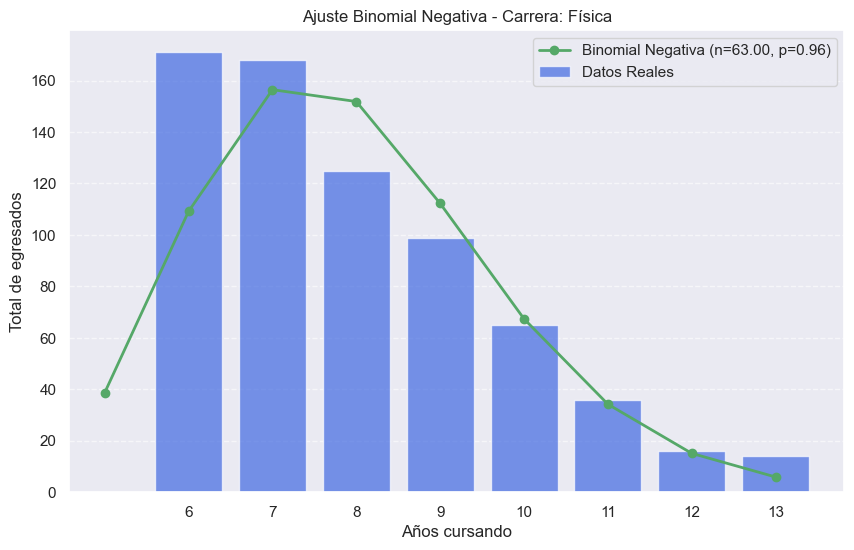

In [36]:
from scipy.stats import binom
import matplotlib.pyplot as plt
p_est = mu / var
n_est = int(round((mu**2) / (var - mu)))

# Eje X para la curva (desde el desplazamiento hacia adelante)
x_teorico = np.arange(0, total_por_tiempo_95['tiempo_cursando'].max() - shift + 1)
y_teorico = nbinom.pmf(x_teorico, n_est, p_est) * total_por_tiempo_95['total_egreso'].sum()

# 4. Graficamos
plt.figure(figsize=(10, 6))

# Barras reales
plt.bar(total_por_tiempo_95['tiempo_cursando'], total_por_tiempo_95['total_egreso'], color='royalblue', alpha=0.7, label='Datos Reales')

# Curva Binomial Negativa
# Nota: sumamos shift para devolver la curva a su posición original en el eje X
plt.plot(x_teorico + shift, y_teorico, 'go-', lw=2, 
            label=f'Binomial Negativa (n={n_est:.2f}, p={p_est:.2f})')

plt.title('Ajuste Binomial Negativa - Carrera: Física')
plt.xlabel('Años cursando')
plt.ylabel('Total de egresados')
plt.xticks(np.arange(int(round(limite_inferior)), int(round(limite_superior)) + 1, 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Ajuste de graficos

Mejor tramo para k=6: 1 a 3, suma=7 (objetivo=7.2)


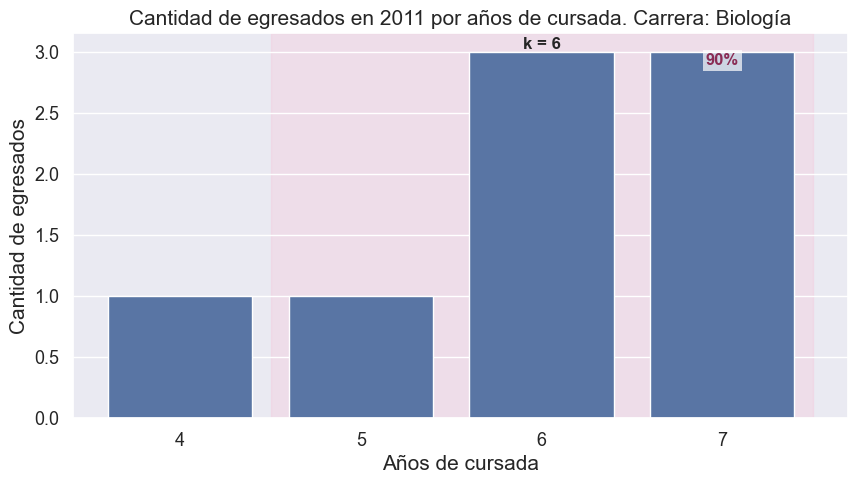

Mejor tramo para k=6: 0 a 2, suma=59 (objetivo=63.0)


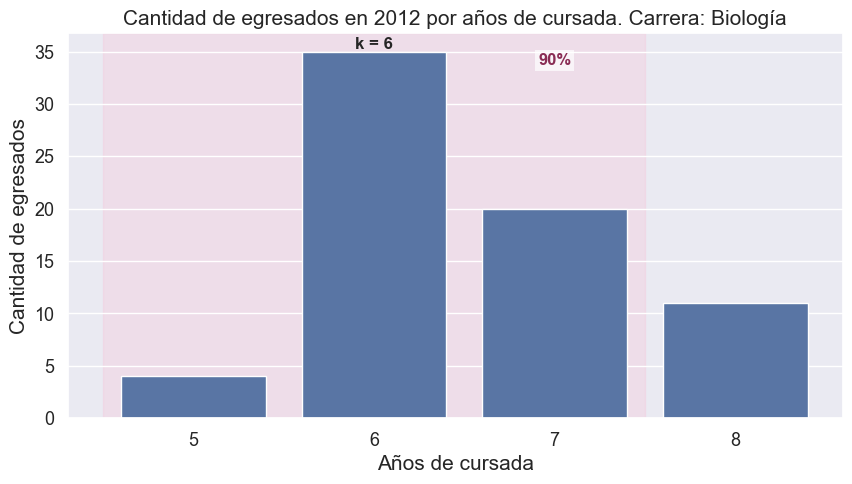

Mejor tramo para k=6: 0 a 3, suma=112 (objetivo=114.3)


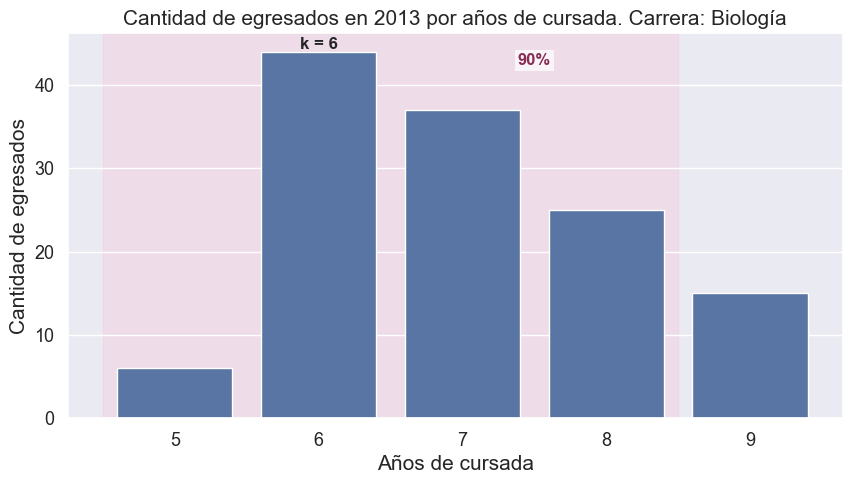

Mejor tramo para k=7: 0 a 4, suma=124 (objetivo=121.5)


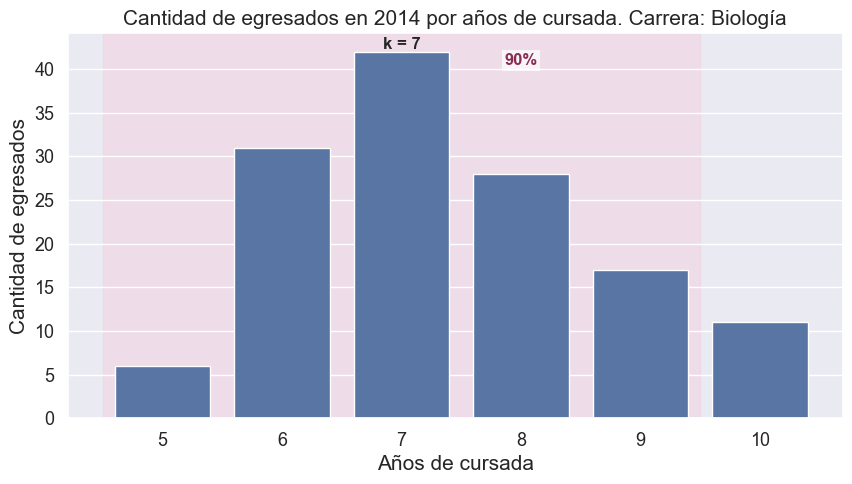

Mejor tramo para k=6: 0 a 5, suma=98 (objetivo=92.7)


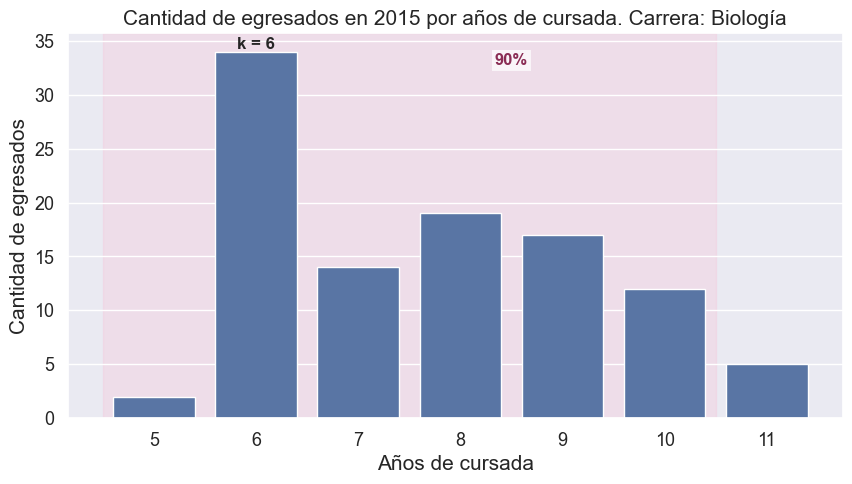

Mejor tramo para k=7: 0 a 4, suma=117 (objetivo=118.8)


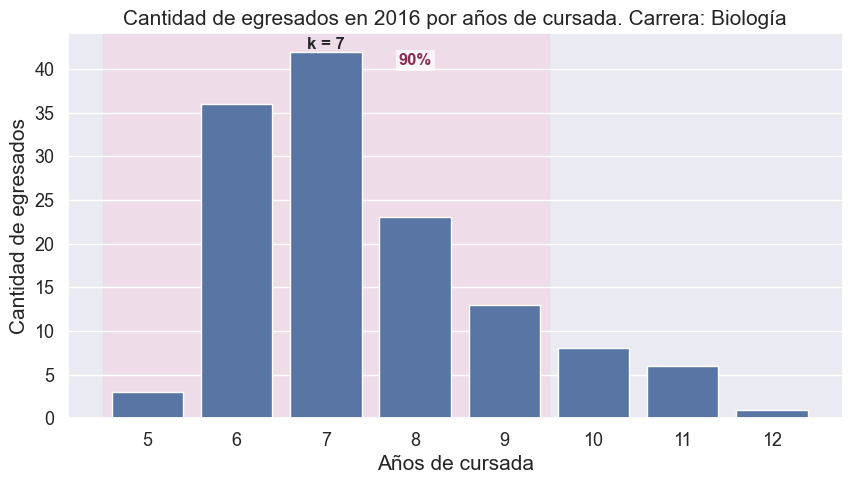

Mejor tramo para k=6: 1 a 7, suma=102 (objetivo=98.1)


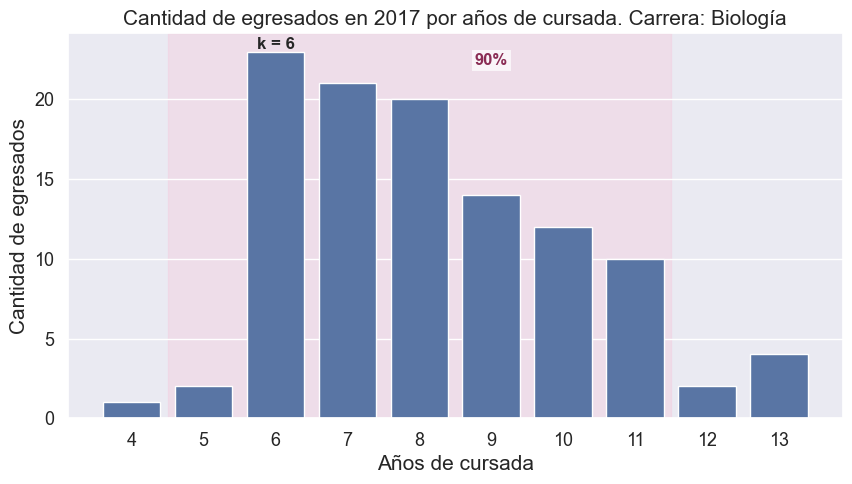

Mejor tramo para k=6: 0 a 6, suma=96 (objetivo=97.2)


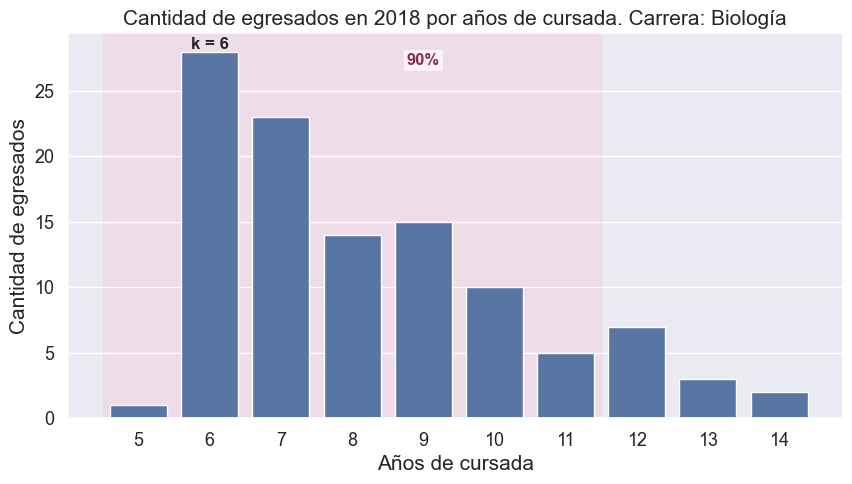

Mejor tramo para k=7: 1 a 7, suma=117 (objetivo=117.0)


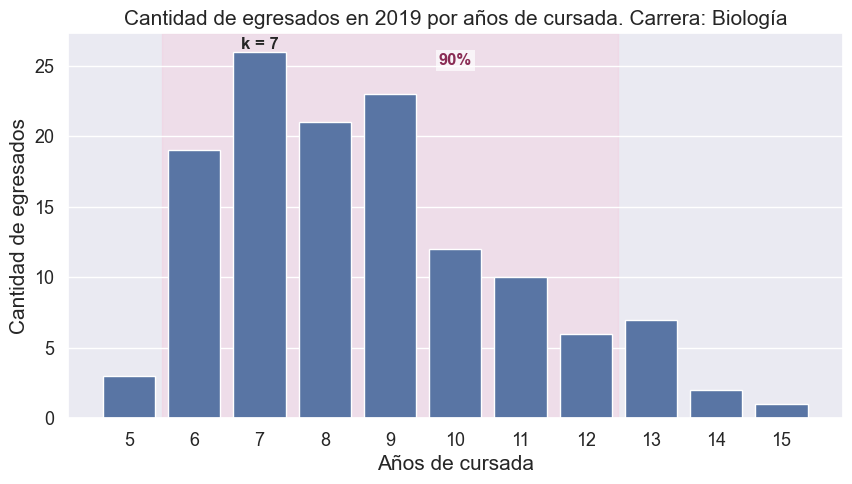

Mejor tramo para k=7: 1 a 7, suma=86 (objetivo=84.6)


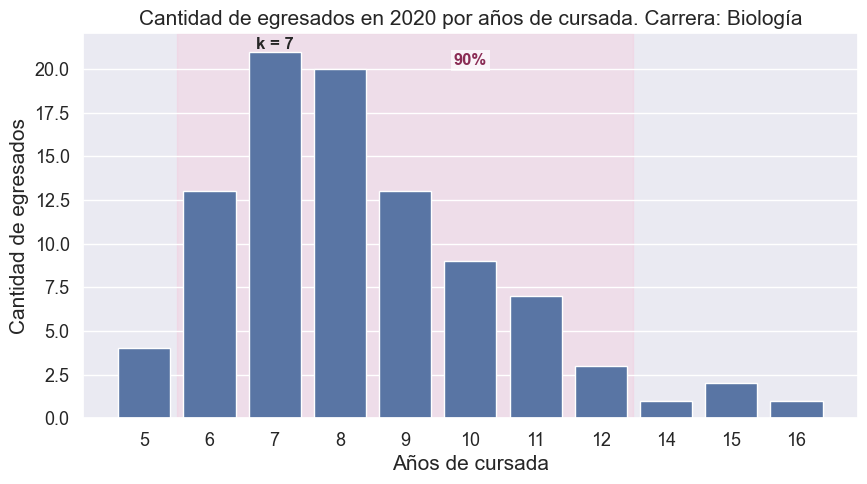

Mejor tramo para k=7: 1 a 8, suma=94 (objetivo=93.6)


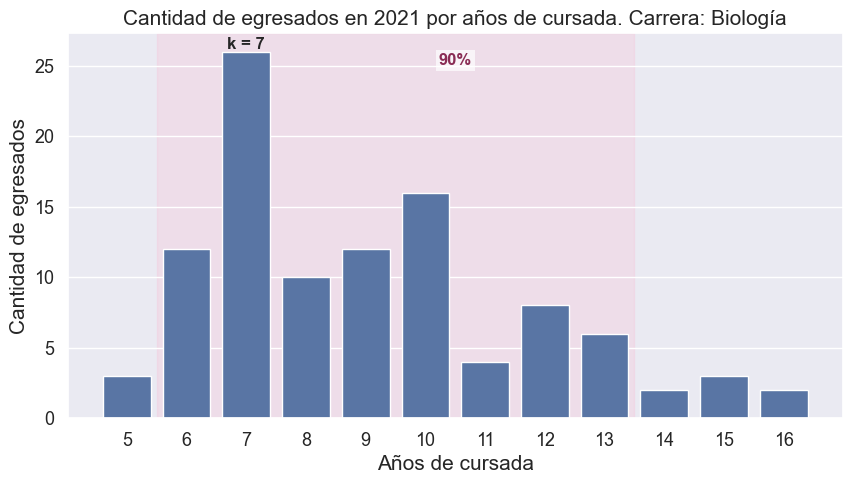

Mejor tramo para k=7: 2 a 11, suma=84 (objetivo=83.7)


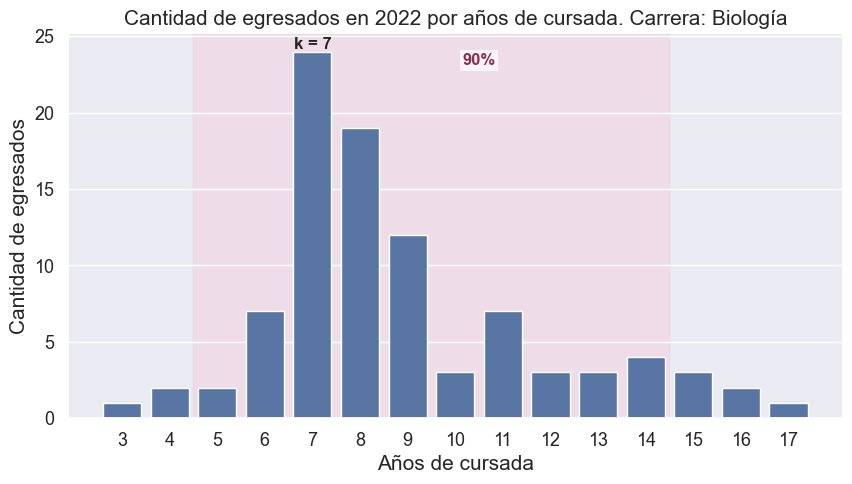

Mejor tramo para k=7: 0 a 7, suma=87 (objetivo=85.5)


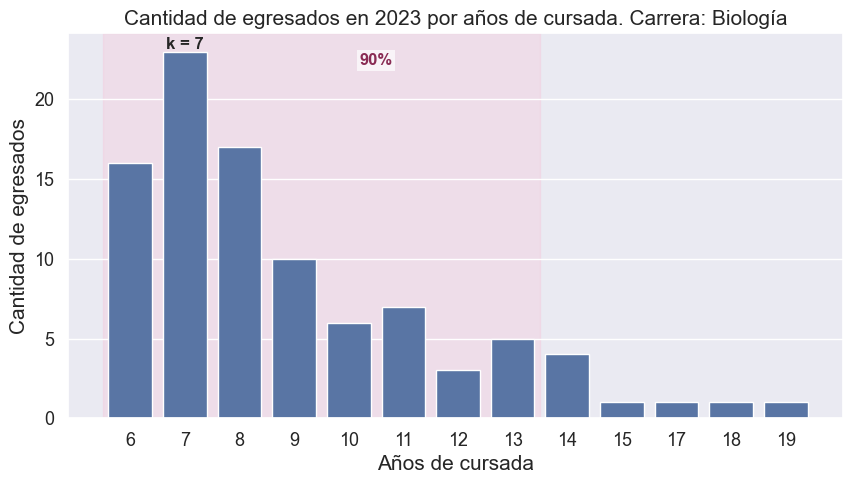

Mejor tramo para k=6: 0 a 7, suma=145 (objetivo=144.9)


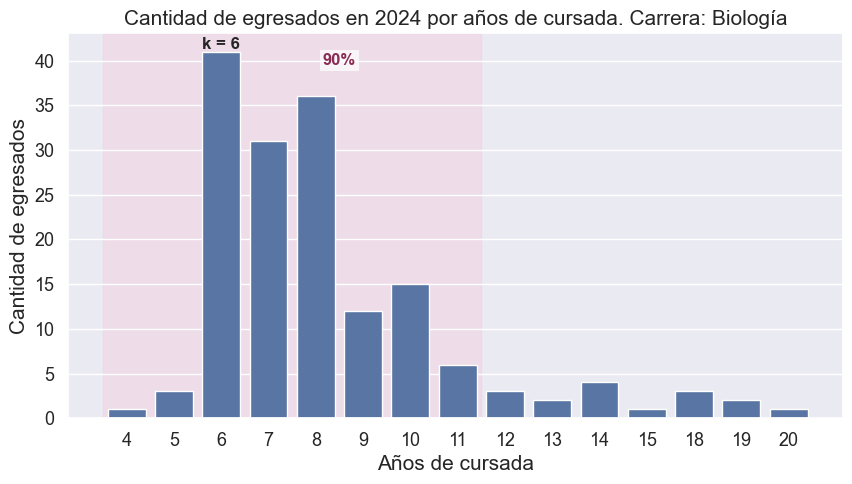

Mejor tramo para k=7: 0 a 7, suma=183 (objetivo=184.5)


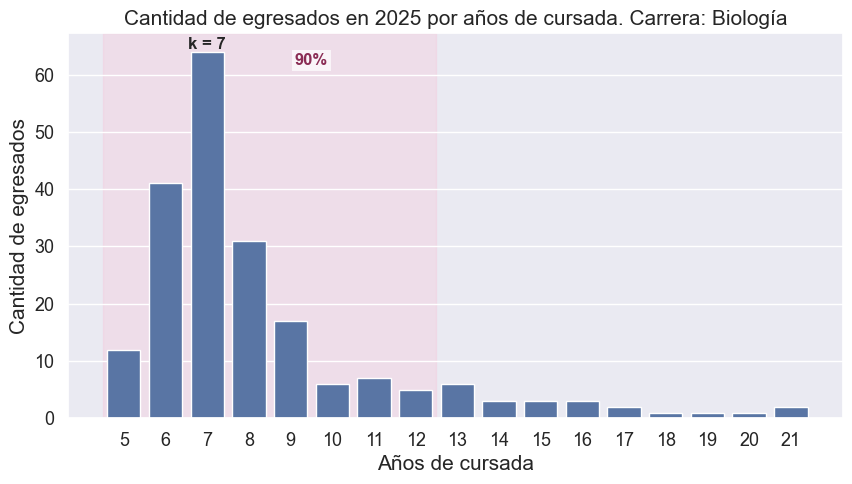

In [37]:
plot_todos_anios_egreso_solo_cantidad_y_k(2011, 2025, "Biología")